<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/EtiquetadoGramatical_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554 Marzo de 2026

Materia: Procesamiento de Lenguaje Natural

Ejercicios: Etiquetado gramatical

# Etiquetado gramatical

Aplique los conceptos de etiquetado gramatical vistos en clase mediante el análisis de un texto en español, y realizar un análisis exploratorio de datos sencillo a partir de las etiquetas obtenidas. El texto para analizar se presenta a continuación:

`En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. Estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. Sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. En algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. Además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. Por esta razón, el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.`


## Instrucciones:

1.	Divida el texto en tokens.



In [38]:
print('Instalar paquete NLTK ...')
!pip install nltk

Instalar paquete NLTK ...


In [39]:
# ==============================
# 1. Importación de librerías
# ==============================
import pandas as pd
import spacy
import nltk
import matplotlib.pyplot as plt
from collections import Counter

In [40]:
# Cargar modelo de spaCy para español
import spacy

try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo 'es_core_news_sm' para spaCy...")
    !python -m spacy download es_core_news_sm
    nlp = spacy.load("es_core_news_sm")

In [41]:
texto = """
En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. Estas tecnologías permiten
organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. Sin embargo, su uso no siempre garantiza mejores
resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. En algunos cursos, los estudiantes participan más cuando
utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. Además, los profesores pueden analizar con mayor facilidad el avance del grupo
y detectar dificultades en temas específicos. Por esta razón, el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.
"""

In [42]:
def tokenizar(texto: str, nlp, top_n: int = 10) -> list[str]:
    """
    Tokeniza un texto con spaCy

    Args:
        texto:  Texto a procesar.
        nlp:    Modelo de spaCy cargado (ej: spacy.load('es_core_news_sm')).
        top_n:  Cantidad de palabras más frecuentes a mostrar en el gráfico de barras.

    Returns:
        Lista de tokens crudos extraídos del texto.
    """
    # Tokenización
    doc = nlp(texto)
    tokens = [token.text for token in doc]
    print("\n=== Tokens ===")
    print(tokens)

    # Frecuencia de palabras
    counter = Counter(tokens)
    most_common = counter.most_common(top_n)
    palabras, freqs = zip(*most_common)

    plt.figure(figsize=(10, 5))
    plt.bar(palabras, freqs)
    plt.title(f"Frecuencia de palabras - Top {top_n} (tokens crudos)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


    return tokens


=== Tokens ===
['\n', 'En', 'los', 'últimos', 'años', ',', 'muchas', 'universidades', 'han', 'incorporado', 'herramientas', 'digitales', 'para', 'apoyar', 'el', 'aprendizaje', 'de', 'los', 'estudiantes', '.', 'Estas', 'tecnologías', 'permiten', '\n', 'organizar', 'materiales', ',', 'facilitar', 'la', 'comunicación', 'y', 'ofrecer', 'actividades', 'interactivas', 'dentro', 'y', 'fuera', 'del', 'aula', '.', 'Sin', 'embargo', ',', 'su', 'uso', 'no', 'siempre', 'garantiza', 'mejores', '\n', 'resultados', 'académicos', ',', 'porque', 'también', 'depende', 'de', 'la', 'planeación', 'del', 'docente', 'y', 'del', 'compromiso', 'del', 'alumno', '.', 'En', 'algunos', 'cursos', ',', 'los', 'estudiantes', 'participan', 'más', 'cuando', '\n', 'utilizan', 'plataformas', 'virtuales', ',', 'foros', 'o', 'sistemas', 'de', 'retroalimentación', 'inmediata', '.', 'Además', ',', 'los', 'profesores', 'pueden', 'analizar', 'con', 'mayor', 'facilidad', 'el', 'avance', 'del', 'grupo', '\n', 'y', 'detectar', '

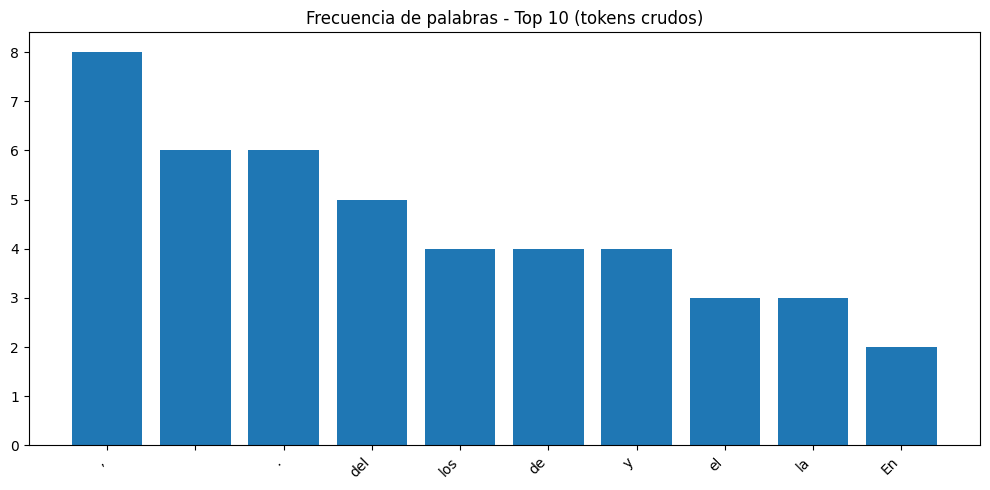

Número de tokens: 131


In [43]:
tokens = tokenizar(texto, nlp, top_n=10)
print('Número de tokens:',len(tokens))



2.	Asigne a cada token su etiqueta gramatical correspondiente utilizando alguno de los ejemplos de la presentación del tema que está en el campus virtual.



In [44]:
import nltk
from nltk.corpus import cess_esp
from nltk.tag import hmm

# 1. Descargar el corpus en español
nltk.download("cess_esp")

[nltk_data] Downloading package cess_esp to /root/nltk_data...
[nltk_data]   Package cess_esp is already up-to-date!


True

In [45]:
# =========================
# 2. Preparar datos en Español
# =========================
# CESS_ESP contiene oraciones ya etiquetadas en español
frases_etiquetadas = cess_esp.tagged_sents()

# Dividimos: 90% entrenamiento, 10% prueba
split = int(len(frases_etiquetadas) * 0.9)
train_data = frases_etiquetadas[:split]
test_data  = frases_etiquetadas[split:]

# =========================
# 3. Entrenar el HMM (Hidden Markov Model)
# =========================
# Usamos un estimador de Lidstone para manejar palabras desconocidas (suavizado)
estimator = lambda fd, bins: nltk.LidstoneProbDist(fd, 0.1, bins)
trainer = hmm.HiddenMarkovModelTrainer()
hmm_tagger = trainer.train_supervised(train_data, estimator=estimator)

# =========================
# 4. Evaluar el modelo
# =========================
accuracy = hmm_tagger.accuracy(test_data)
print(f"Precisión del etiquetado HMM (CESS_ESP Español): {accuracy:.4f}")

Precisión del etiquetado HMM (CESS_ESP Español): 0.8490


In [46]:
# =========================
# 5. Aplicar a tokens
# =========================
# Limpiamos los tokens de saltos de línea
tokens_limpios = [t for t in tokens if t.strip()]

print("\nResultado del etiquetado en español:")
resultado = hmm_tagger.tag(tokens_limpios)
for palabra, etiqueta in resultado:
    print(f"{palabra} -> {etiqueta}")


Resultado del etiquetado en español:
En -> sps00
los -> da0mp0
últimos -> ao0mp0
años -> ncmp000
, -> Fc
muchas -> di0fp0
universidades -> ncfp000
han -> vaip3p0
incorporado -> vmp00sm
herramientas -> ncfp000
digitales -> aq0cp0
para -> sps00
apoyar -> vmn0000
el -> da0ms0
aprendizaje -> ncms000
de -> sps00
los -> da0mp0
estudiantes -> nccp000
. -> Fp
Estas -> dd0fp0
tecnologías -> ncfp000
permiten -> vmip3p0
organizar -> vmn0000
materiales -> ncmp000
, -> Fc
facilitar -> vmn0000
la -> da0fs0
comunicación -> ncfs000
y -> cc
ofrecer -> vmn0000
actividades -> ncfp000
interactivas -> aq0fp0
dentro -> rg
y -> cc
fuera -> rg
del -> spcms
aula -> ncms000
. -> Fp
Sin -> dp1css
embargo -> ncms000
, -> Fc
su -> dp3cs0
uso -> ncms000
no -> rn
siempre -> rg
garantiza -> vmip3s0
mejores -> aq0cp0
resultados -> ncmp000
académicos -> aq0mp0
, -> Fc
porque -> cs
también -> rg
depende -> vmip3s0
de -> sps00
la -> da0fs0
planeación -> ncfs000
del -> spcms
docente -> np0000o
y -> cc
del -> spcms
compro

3.	Realice un análisis exploratorio de datos con la información obtenida donde muestre:
- a.	El número total de tokens
- b.	Número de tokens distintos
- c.	Conteo de cada categoría gramatical en una gráfica de barras
- d.	Los cinco tokens más frecuentes del texto con sus respectivas etiquetas gramaticales en una gráfica de barras
- e.	Las tres clases gramaticales más frecuentes del texto en una gráfica de barras



In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

a) Número total de tokens: 125
b) Número de tokens distintos: 91


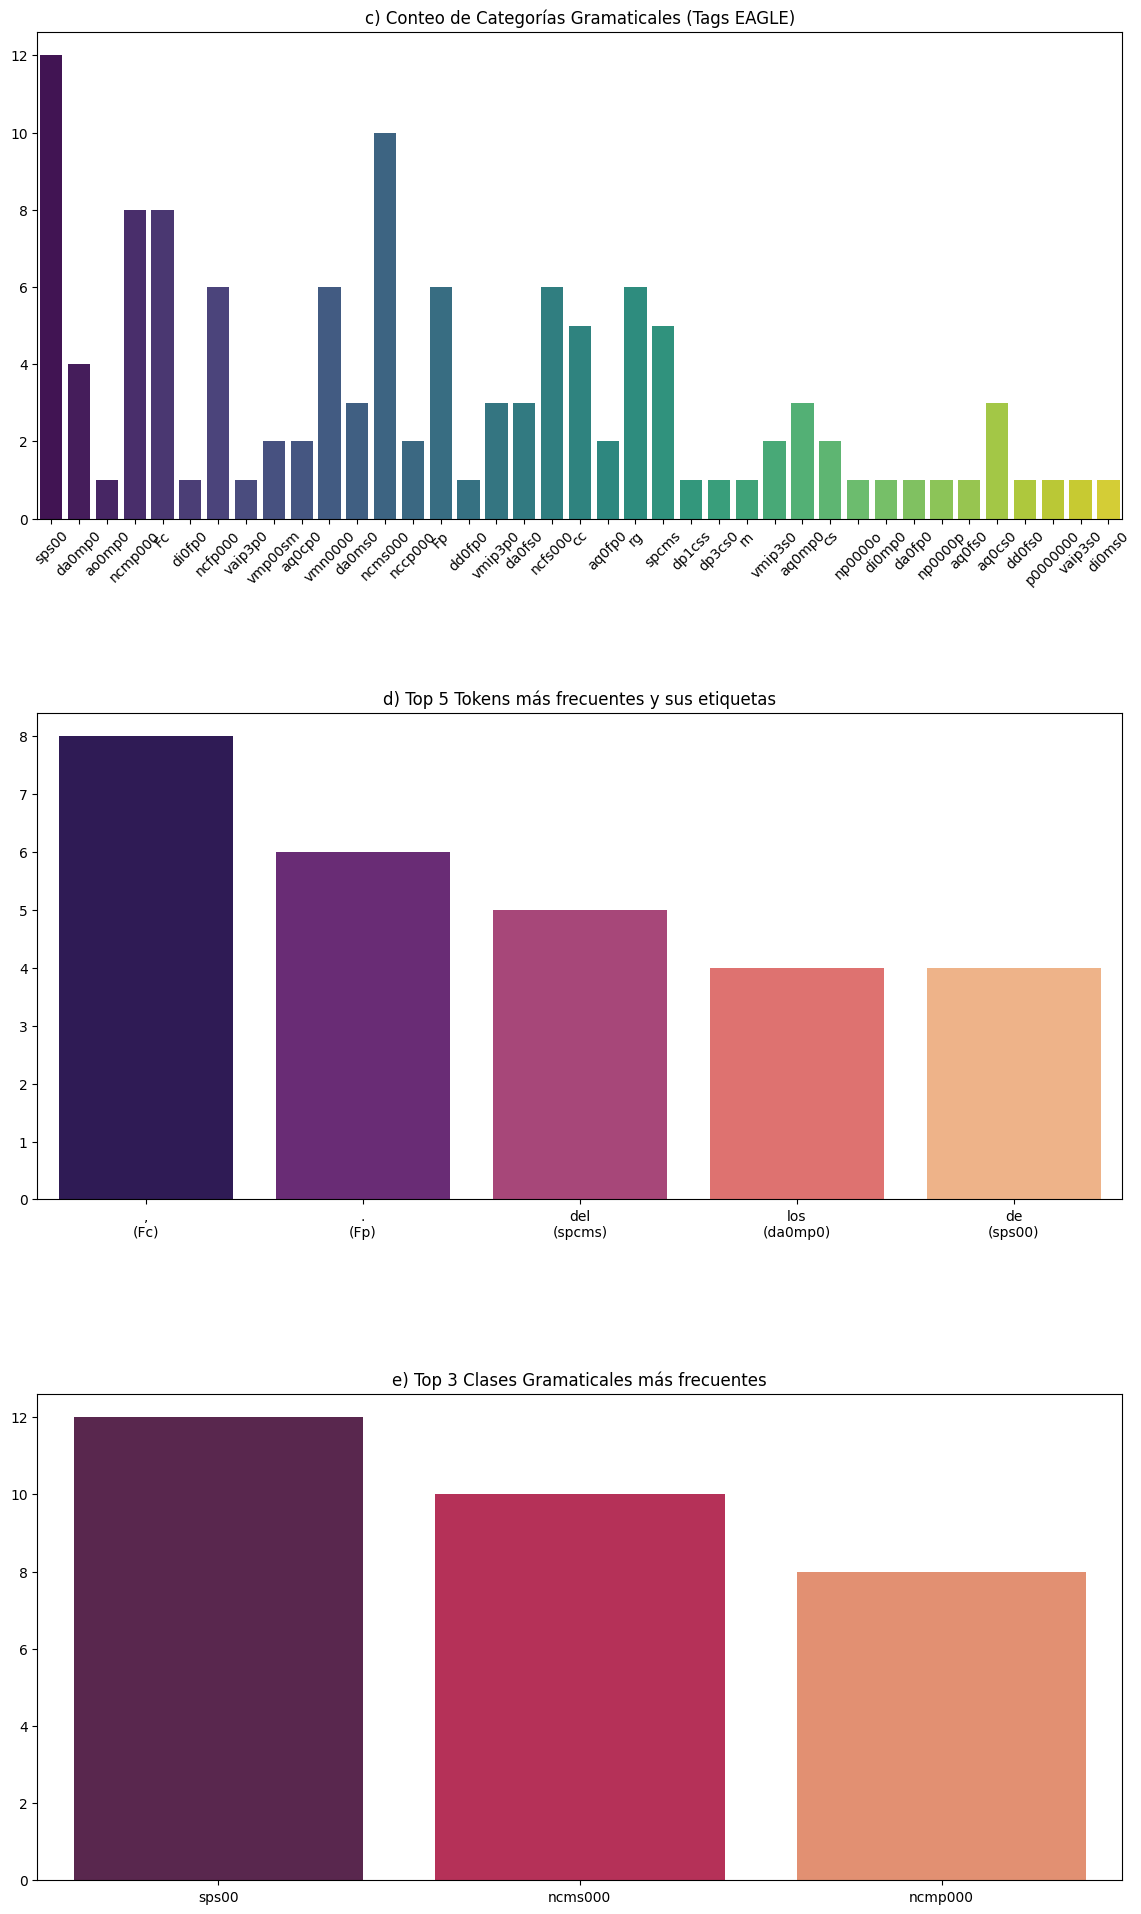

In [48]:
# Filtramos saltos de línea y espacios
tokens_limpios = [t for t in tokens if t.strip()]
tokens_etiquetados = hmm_tagger.tag(tokens_limpios)

# Separar tokens y etiquetas para facilitar el conteo
solo_tokens = [t for t, tag in tokens_etiquetados]
solo_etiquetas = [tag for t, tag in tokens_etiquetados]

# Métricas de tokens
total_tokens = len(solo_tokens)
tokens_distintos = len(set(solo_tokens))

print(f"a) Número total de tokens: {total_tokens}")
print(f"b) Número de tokens distintos: {tokens_distintos}")

# Gráficas
fig, axes = plt.subplots(3, 1, figsize=(14, 24))
plt.subplots_adjust(hspace=0.4)

# Conteo de cada categoría gramatical
conteo_tags = Counter(solo_etiquetas)
etiquetas= list(conteo_tags.keys())
conteo_cat= list(conteo_tags.values())
sns.barplot(x=etiquetas, y=conteo_cat, ax=axes[0], hue=etiquetas, legend=False ,palette="viridis")
axes[0].set_title("c) Conteo de Categorías Gramaticales (Tags EAGLE)")
axes[0].tick_params(axis='x', rotation=45)

# Cinco tokens más frecuentes con sus etiquetas
# Creamos una representación combinada: "token (TAG)"
token_tag_comb = [f"{t}\n({tag})" for t, tag in tokens_etiquetados]
top_5_tokens = Counter(token_tag_comb).most_common(5)
words, counts = zip(*top_5_tokens)

palabras = list(words)
conteo_pal= list(counts)
sns.barplot(x=palabras, y=conteo_pal, ax=axes[1], hue=palabras, legend=False ,palette="magma")
axes[1].set_title("d) Top 5 Tokens más frecuentes y sus etiquetas")

# Tres clases gramaticales más frecuentes
top_3_tags = conteo_tags.most_common(3)
tags_nombres, tags_counts = zip(*top_3_tags)

nombres_tag= list(tags_nombres)
conteo_tags= list(tags_counts)
sns.barplot(x=nombres_tag, y=conteo_tags, ax=axes[2], hue=nombres_tag, legend=False, palette="rocket")
axes[2].set_title("e) Top 3 Clases Gramaticales más frecuentes")

plt.show()

## ANÁLISIS CON FILTRADO DE STOPWORDS

In [49]:
from nltk.corpus import stopwords

# Asegúrate de tener descargado el recurso de stopwords
nltk.download('stopwords')

# Definimos el conjunto de palabras vacías en español
stop_words_es = set(stopwords.words('spanish'))

# Filtramos saltos de línea, espacios, puntuación Y stopwords
tokens_limpios = [
    t for t in tokens
    if t.strip() and t.lower() not in stop_words_es and len(t) > 1
]

# Limpiar Tokens
tokens_etiquetados = hmm_tagger.tag(tokens_limpios)

# Separar tokens y etiquetas
solo_tokens = [t for t, tag in tokens_etiquetados]
solo_etiquetas = [tag for t, tag in tokens_etiquetados]

# Métricas actualizadas
total_tokens = len(solo_tokens)
tokens_distintos = len(set(solo_tokens))

print(f"a) Número total de tokens (sin stopwords): {total_tokens}")
print(f"b) Número de tokens distintos: {tokens_distintos}")

a) Número total de tokens (sin stopwords): 64
b) Número de tokens distintos: 62


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


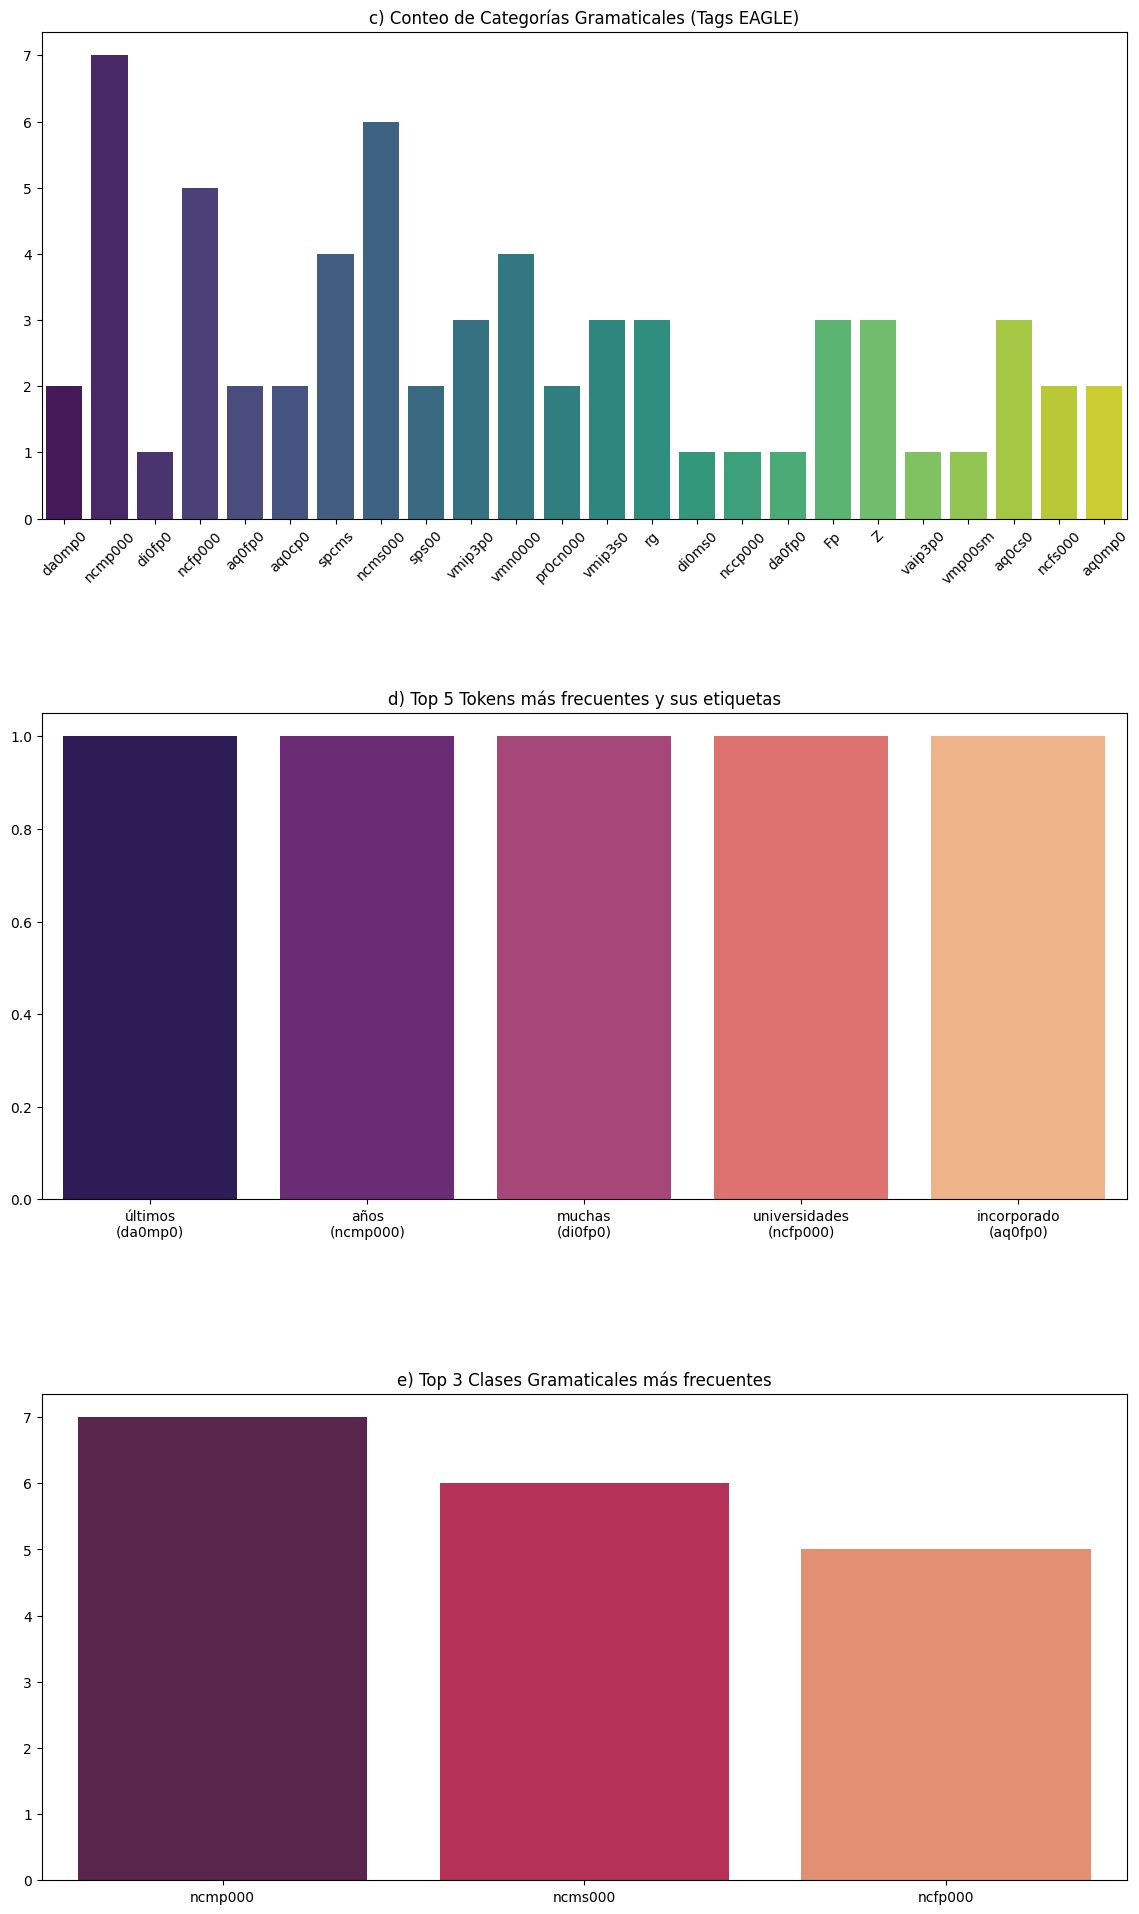

In [50]:
# Gráficas
fig, axes = plt.subplots(3, 1, figsize=(14, 24))
plt.subplots_adjust(hspace=0.4)

# Conteo de cada categoría gramatical
conteo_tags = Counter(solo_etiquetas)
etiquetas= list(conteo_tags.keys())
conteo_cat= list(conteo_tags.values())
sns.barplot(x=etiquetas, y=conteo_cat, ax=axes[0], hue=etiquetas, legend=False ,palette="viridis")
axes[0].set_title("c) Conteo de Categorías Gramaticales (Tags EAGLE)")
axes[0].tick_params(axis='x', rotation=45)

# Cinco tokens más frecuentes con sus etiquetas
# Creamos una representación combinada: "token (TAG)"
token_tag_comb = [f"{t}\n({tag})" for t, tag in tokens_etiquetados]
top_5_tokens = Counter(token_tag_comb).most_common(5)
words, counts = zip(*top_5_tokens)

palabras = list(words)
conteo_pal= list(counts)
sns.barplot(x=palabras, y=conteo_pal, ax=axes[1], hue=palabras, legend=False ,palette="magma")
axes[1].set_title("d) Top 5 Tokens más frecuentes y sus etiquetas")

# Tres clases gramaticales más frecuentes
top_3_tags = conteo_tags.most_common(3)
tags_nombres, tags_counts = zip(*top_3_tags)

nombres_tag= list(tags_nombres)
conteo_tags= list(tags_counts)
sns.barplot(x=nombres_tag, y=conteo_tags, ax=axes[2], hue=nombres_tag, legend=False, palette="rocket")
axes[2].set_title("e) Top 3 Clases Gramaticales más frecuentes")

plt.show()

4.	Redacte una conclusión sobre el texto y su etiquetado gramatical.

Se concluye que es de suma importancia definir si haremos limpieza de stopwords en nuestro análisis, ya que el resultado puede variar con o sin stopwords. Podemos observar que las gráficas antes de la limpieza muestra como resultado dentro del top 5, solo stopwords, mientras que después de la limpieza observamos palabras que pueden resultar interesantes para el análisis semántico de textos.

